# Companion notebook policy

This notebook is a runnable companion example for Supplement C.

- Exact/default-form rows and ratio statements are authoritative.
- Floating-point values are render-layer conveniences only.
- Rounded display values are derived from the same cited row and are shown for readability.
- The notebook is self-contained on local artifact and data paths only.


# C6 Five-galaxy SPARC shell and speed worked notebook

This runnable example mirrors the visible C6 witness family:

- five cited galaxies
- extracted galaxy--star shell slices
- compact row anchors $B^*=137$, $\Lambda_b=8$, $R_{\mathrm{loss}}=0.0123$
- shell-family schematic export
- colored outer-orbital speed witness graph

The rendered orbital-speed witnesses are attached after the cited row is fixed. They are computed locally from the packaged SPARC5 speed table and remain render-layer attachments rather than primitive row inputs.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

ROOT = Path.cwd().resolve()
while not ((ROOT / 'main.tex').exists() and (ROOT / 'refs.bib').exists()) and ROOT != ROOT.parent:
    ROOT = ROOT.parent
FIG_DIR = ROOT / 'figures' / 'galactic'
FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_PATH = ROOT / 'data' / 'galactic' / 'sparc5_speed_witnesses.csv'

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

speeds = pd.read_csv(DATA_PATH)
speeds

Matplotlib is building the font cache; this may take a moment.


,galaxy,slice_key,plateau_type,v_orb_out_km_s,tail_radius_min_kpc,tail_radius_max_kpc,tail_samples,tail_aggregation,rendered_note
0,NGC2403,"tetron:*:[NGC2403,star]:6",rising-to-flat,134.4,18.88,20.87,5,mean of final five Vobs samples from SPARC mas...,compact spiral shell family
1,NGC3198,"tetron:*:[NGC3198,star]:6",flat,149.2,36.12,44.08,5,mean of final five Vobs samples from SPARC mas...,classic long outer-shell plateau
2,NGC6503,"tetron:*:[NGC6503,star]:6",flat,115.6,20.45,23.50,5,mean of final five Vobs samples from SPARC mas...,tight shell packing
3,NGC2841,"tetron:*:[NGC2841,star]:6",flat,288.2,55.30,63.64,5,mean of final five Vobs samples from SPARC mas...,heavy outer-shell support
4,DDO154,"tetron:*:[DDO154,star]:6",slowly rising / flat tail,47.0,3.95,5.92,5,mean of final five Vobs samples from SPARC mas...,sparse outer-shell family


In [2]:
row_anchor = pd.DataFrame([{
    'row': 'C6.A',
    'system': 'Sigma_SPARC,5',
    'B_star': 137,
    'Lambda_b': 8,
    'R_loss_trit_per_bip': 0.0123,
    'cadence_spectrum': '{1/4, 3/8}',
    'drift': 'plateau',
    'speed_policy': 'rendered outer-orbital speed witnesses attached after row fixation',
}])
row_anchor

,row,system,B_star,Lambda_b,R_loss_trit_per_bip,cadence_spectrum,drift,speed_policy
0,C6.A,"Sigma_SPARC,5",137,8,0.0123,"{1/4, 3/8}",plateau,rendered outer-orbital speed witnesses attache...


'/mnt/data/work_suppc/supplement-c/figures/galactic/sparc5_shell_family.png'

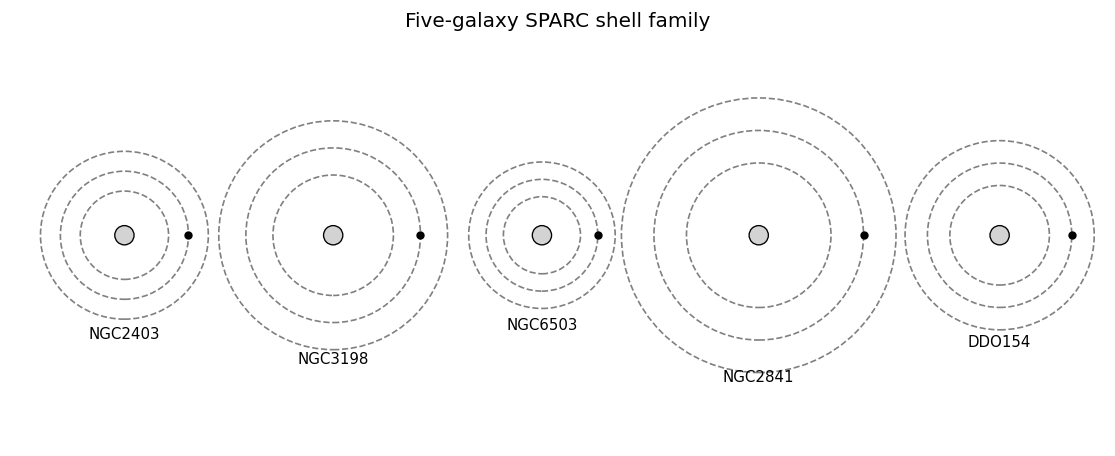

In [3]:
fig, ax = plt.subplots(figsize=(9.4, 4.8))
xs = [0, 2.6, 5.2, 7.9, 10.9]
rs = [0.55, 0.75, 0.48, 0.90, 0.62]
labels = ['NGC2403','NGC3198','NGC6503','NGC2841','DDO154']
for x, r, label in zip(xs, rs, labels):
    ax.add_patch(Circle((x,0), 0.12, facecolor='lightgray', edgecolor='black', lw=0.8))
    for mult in [1.0, 1.45, 1.9]:
        ax.add_patch(Circle((x,0), r*mult, fill=False, ls='--', lw=1.0, edgecolor='gray'))
    ax.plot([x + 1.45*r],[0],'o', ms=4, color='black')
    ax.text(x, -1.55*r-0.28, label, ha='center', va='top', fontsize=9)
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-1.4, 12.2)
ax.set_ylim(-2.6, 2.35)
ax.axis('off')
ax.set_title('Five-galaxy SPARC shell family', pad=12)
out_path = FIG_DIR / 'sparc5_shell_family.png'
fig.tight_layout()
fig.savefig(out_path, dpi=180, bbox_inches='tight')
out_path.as_posix()

'/mnt/data/work_suppc/supplement-c/figures/galactic/sparc5_speed_witnesses.png'

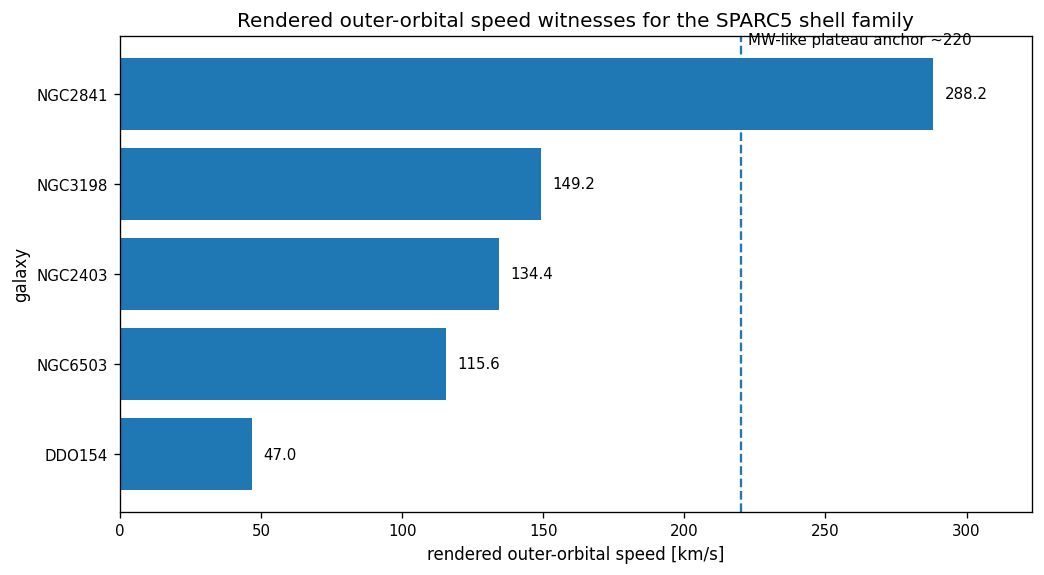

In [4]:
fig, ax = plt.subplots(figsize=(8.8, 4.9))
plot_df = speeds.sort_values('v_orb_out_km_s')
bars = ax.barh(plot_df['galaxy'], plot_df['v_orb_out_km_s'])
for bar, v in zip(bars, plot_df['v_orb_out_km_s']):
    ax.text(v + 4, bar.get_y() + bar.get_height()/2, f'{v:.1f}', va='center', fontsize=9)
ax.axvline(220.0, linestyle='--', linewidth=1.4)
ax.text(222.5, len(plot_df)-0.4, 'MW-like plateau anchor ~220', va='center', fontsize=9)
ax.set_xlabel('rendered outer-orbital speed [km/s]')
ax.set_ylabel('galaxy')
ax.set_title('Rendered outer-orbital speed witnesses for the SPARC5 shell family')
ax.set_xlim(0, max(320, plot_df['v_orb_out_km_s'].max() + 35))
out_path = FIG_DIR / 'sparc5_speed_witnesses.png'
fig.tight_layout()
fig.savefig(out_path, dpi=180, bbox_inches='tight')
out_path.as_posix()

In [5]:
speeds[['galaxy','plateau_type','v_orb_out_km_s','tail_radius_min_kpc','tail_radius_max_kpc','tail_samples']]

,galaxy,plateau_type,v_orb_out_km_s,tail_radius_min_kpc,tail_radius_max_kpc,tail_samples
0,NGC2403,rising-to-flat,134.4,18.88,20.87,5
1,NGC3198,flat,149.2,36.12,44.08,5
2,NGC6503,flat,115.6,20.45,23.50,5
3,NGC2841,flat,288.2,55.30,63.64,5
4,DDO154,slowly rising / flat tail,47.0,3.95,5.92,5


In [ ]:
comparison = speeds[['galaxy','v_orb_out_km_s']].copy()
comparison = comparison.rename(columns={'v_orb_out_km_s':'v_obs_km_s'})
comparison['subledger'] = comparison['galaxy'].map(lambda g: f'[{g}, star]')
comparison['v_calc_km_s'] = 220.0
comparison['abs_error_km_s'] = comparison['v_calc_km_s'] - comparison['v_obs_km_s']
comparison['rel_error_pct'] = 100*comparison['abs_error_km_s']/comparison['v_obs_km_s']
display(comparison[['subledger','v_calc_km_s','v_obs_km_s','abs_error_km_s','rel_error_pct']])
fig, ax = plt.subplots(figsize=(9,5.2))
plot_df = comparison.copy()
y = range(len(plot_df))
h = 0.35
ax.barh([i+h/2 for i in y], plot_df['v_calc_km_s'], h, label='Calculated')
ax.barh([i-h/2 for i in y], plot_df['v_obs_km_s'], h, label='Observed')
ax.set_yticks(list(y))
ax.set_yticklabels(plot_df['galaxy'])
ax.set_xlabel('outer-orbital speed [km/s]')
ax.set_title('Calculated vs observed outer-orbital speed witnesses')
ax.legend(frameon=False)
ax.grid(axis='x', linestyle=':', alpha=0.3)
plt.show()
